In [ ]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

import pandas as pd
import duckdb
from pathlib import Path
from config import PROJECT_ROOT, RESEARCH_ROOT, ARTIFACTS_ROOT, NSE_DB_PATH

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import numpy as np
from scipy import stats

In [2]:
RESEARCH_DB_PATH = RESEARCH_ROOT / "research.db"
con = duckdb.connect(RESEARCH_DB_PATH)
con.execute(f"ATTACH '{NSE_DB_PATH}' AS nse (READ_ONLY)")
RESEARCH_PLOTS_20D = PROJECT_ROOT / "plots/20d"

In [3]:
feature_groups = {
    'price_vol': ['nifty_close', 'vix_close', 'underlying_daily_vol', 'futures_daily_vol', 'applicable_daily_vol'],
    'options_derived': ['pcr', 'max_pain_dist_pct', 'basis', 'cost_of_carry', 'fut_chng_oi_pct'],
    'breadth': ['advances', 'declines', 'adv_decl_ratio', 'price_band_hits', 'traded_value_cr', 'num_trades', 'market_cap_cr'],
    'fii_dii_positioning': ['fii_fut_net_pct', 'client_fut_net_pct', 'fii_pe_net_pct', 'fii_net_flow_cr',
                            'dii_fut_net_pct', 'pro_fut_net_pct', 'fii_stk_fut_net_pct', 'client_stk_fut_net_pct'],
    'options_skew': ['fii_opt_skew_pct', 'client_opt_skew_pct', 'dii_opt_skew_pct', 'pro_opt_skew_pct',
                      'fii_vol_opt_skew_pct', 'client_vol_opt_skew_pct'],
    'vol_futures_flow': ['fii_vol_fut_net_pct', 'client_vol_fut_net_pct', 'pro_vol_fut_net_pct'],
    'divergence_stats': ['fii_client_divergence', 'fii_stats_fut_net_pct', 'fii_stats_oi_net_cr'],
    'engineered_deltas': ['vix_chg_5d', 'pcr_chg_5d', 'basis_chg_5d', 'max_pain_dist_chg_5d', 
                           'vix_realized_spread', 'fii_fut_net_chg_5d'],
    'targets': ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d', 'up_1d']
}

emission_raw = ['vix_close', 'underlying_daily_vol', 'price_band_hits', 
                 'fii_stats_fut_net_pct', 'client_opt_skew_pct', 'max_pain_dist_pct', 'basis_chg_5d']

In [4]:
df_work = pd.read_csv(RESEARCH_ROOT / '8_state_data.csv', index_col=0, parse_dates=True)
print(df_work.shape)
print(df_work['hmm_state_v2'].notna().sum(), "rows with HMM state")

model_df = df_work.dropna(subset=['hmm_state_v2']).copy()
model_df['hmm_state_v2'] = model_df['hmm_state_v2'].astype(int)

target = 'fwd_ret_20d'
feature_cols_model = [c for c in [c for g,cols in feature_groups.items() if g!='targets' for c in cols] 
                       if c not in emission_raw]  # exclude HMM's own inputs

model_df = model_df.dropna(subset=[target] + feature_cols_model)
print(f"\nUsable rows: {len(model_df)}")
print(f"Date range: {model_df.index.min()} to {model_df.index.max()}")
print(f"Feature count: {len(feature_cols_model)}")

(2616, 48)
2552 rows with HMM state

Usable rows: 2411
Date range: 2016-04-06 00:00:00 to 2026-06-29 00:00:00
Feature count: 36


In [5]:
expiries = con.execute("""
    SELECT DISTINCT expiry
    FROM nse.instruments
    WHERE ticker = 'NIFTY'
      AND expiry IS NOT NULL
    ORDER BY expiry
""").fetchdf()

expiries['expiry'] = pd.to_datetime(expiries['expiry'])

# filter to within our actual data range — drops the far-dated 2029 etc futures listings
expiries_in_range = expiries[(expiries['expiry'] >= df_work.index.min()) & 
                               (expiries['expiry'] <= df_work.index.max())]
print(f"Total distinct expiries in range: {len(expiries_in_range)}")

# monthly = last expiry of each calendar month (standard convention: last Thursday, 
# even after weekly expiries started, the LAST expiry of the month is still "the monthly")
expiries_in_range = expiries_in_range.copy()
expiries_in_range['year_month'] = expiries_in_range['expiry'].dt.to_period('M')
monthly_expiries = expiries_in_range.groupby('year_month')['expiry'].max().reset_index(drop=True)

print(f"\nMonthly expiries identified: {len(monthly_expiries)}")
print(monthly_expiries.head(10))
print(monthly_expiries.tail(10))

# compare to our cost_of_carry NaN proxy
coc_nan_dates = set(df_work[df_work['cost_of_carry'].isna()].index.date)
monthly_expiry_dates = set(monthly_expiries.dt.date)

print(f"\ncost_of_carry NaN count: {len(coc_nan_dates)}")
print(f"True monthly expiry count: {len(monthly_expiry_dates)}")
print(f"In both: {len(coc_nan_dates & monthly_expiry_dates)}")
print(f"In coc_nan but NOT true monthly expiry: {sorted(coc_nan_dates - monthly_expiry_dates)[:10]}")
print(f"In true monthly expiry but NOT coc_nan: {sorted(monthly_expiry_dates - coc_nan_dates)[:10]}")

Total distinct expiries in range: 434

Monthly expiries identified: 127
0   2016-01-28
1   2016-02-25
2   2016-03-31
3   2016-04-28
4   2016-05-26
5   2016-06-30
6   2016-07-28
7   2016-08-25
8   2016-09-29
9   2016-10-27
Name: expiry, dtype: datetime64[us]
117   2025-10-28
118   2025-11-25
119   2025-12-30
120   2026-01-27
121   2026-02-24
122   2026-03-31
123   2026-04-28
124   2026-05-26
125   2026-06-30
126   2026-07-21
Name: expiry, dtype: datetime64[us]

cost_of_carry NaN count: 126
True monthly expiry count: 127
In both: 121
In coc_nan but NOT true monthly expiry: [datetime.date(2018, 3, 28), datetime.date(2023, 3, 29), datetime.date(2023, 6, 28), datetime.date(2025, 4, 24), datetime.date(2026, 3, 30)]
In true monthly expiry but NOT coc_nan: [datetime.date(2018, 3, 29), datetime.date(2023, 3, 30), datetime.date(2023, 6, 29), datetime.date(2025, 4, 30), datetime.date(2026, 3, 31), datetime.date(2026, 7, 21)]


In [6]:
# use only expiries that have actually occurred within our data
valid_monthly_expiries = monthly_expiries[monthly_expiries <= df_work.index.max()].reset_index(drop=True)
print(f"Usable monthly expiry boundaries: {len(valid_monthly_expiries)}")

# walk-forward: train up to expiry[i], test = the period between expiry[i] and expiry[i+1]
# start after we have a reasonable minimum training history (e.g. first 24 expiries ~ 2 years)
min_train_expiries = 24
embargo_days = 20  # same overlap-purge logic as before, for fwd_ret_20d

folds = []
for i in range(min_train_expiries, len(valid_monthly_expiries) - 1):
    train_end = valid_monthly_expiries.iloc[i]
    test_start = valid_monthly_expiries.iloc[i]
    test_end = valid_monthly_expiries.iloc[i + 1]
    
    train_mask = model_df.index <= (train_end - pd.Timedelta(days=embargo_days))
    test_mask = (model_df.index > test_start) & (model_df.index <= test_end)
    
    train_idx = model_df.index[train_mask]
    test_idx = model_df.index[test_mask]
    
    if len(train_idx) < 100 or len(test_idx) < 5:
        continue
    folds.append({'train_idx': train_idx, 'test_idx': test_idx, 
                   'train_end': train_end, 'test_start': test_start, 'test_end': test_end})

print(f"\nTotal folds: {len(folds)}")
for f in folds[:3] + folds[-3:]:
    print(f"train ends {f['train_end'].date()} | test: {f['test_start'].date()} to {f['test_end'].date()} "
          f"| train n={len(f['train_idx'])}, test n={len(f['test_idx'])}")

Usable monthly expiry boundaries: 127

Total folds: 101
train ends 2018-01-25 | test: 2018-01-25 to 2018-02-22 | train n=415, test n=17
train ends 2018-02-22 | test: 2018-02-22 to 2018-03-29 | train n=433, test n=22
train ends 2018-03-29 | test: 2018-03-29 to 2018-04-26 | train n=455, test n=18
train ends 2026-03-31 | test: 2026-03-31 to 2026-04-28 | train n=2343, test n=17
train ends 2026-04-28 | test: 2026-04-28 to 2026-05-26 | train n=2359, test n=18
train ends 2026-05-26 | test: 2026-05-26 to 2026-06-30 | train n=2376, test n=22


In [7]:
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

interaction_feats = ['futures_daily_vol', 'fii_stk_fut_net_pct', 'dii_opt_skew_pct']

def build_interaction_matrix(df, base_feats, interaction_feats, n_states=8):
    X = df[base_feats].copy()
    state_dummies = pd.get_dummies(df['hmm_state_v2'], prefix='state')
    for feat in interaction_feats:
        for s in range(n_states):
            X[f'{feat}_x_state{s}'] = df[feat] * (df['hmm_state_v2'] == s).astype(int)
    return pd.concat([X, state_dummies], axis=1)

base_feats = [c for c in feature_cols_model if c not in interaction_feats]

fold_results_linear = []
all_preds, all_y_test = [], []

for i, f in enumerate(folds):
    train = model_df.loc[f['train_idx']]
    test = model_df.loc[f['test_idx']]

    X_train = build_interaction_matrix(train, base_feats, interaction_feats)
    X_test = build_interaction_matrix(test, base_feats, interaction_feats)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train, y_test = train[target], test[target]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = Ridge(alpha=10.0)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)

    all_preds.append(preds)
    all_y_test.append(y_test.values)

    fold_results_linear.append({
        'fold': i,
        'test_start': f['test_start'],
        'ic': np.corrcoef(preds, y_test)[0,1] if len(y_test) > 2 else np.nan,
        'ic_spearman': spearmanr(preds, y_test)[0] if len(y_test) > 2 else np.nan,
        'mse': np.mean((preds - y_test)**2),
        'n': len(y_test)
    })

linear_results_df = pd.DataFrame(fold_results_linear)
print(linear_results_df[['ic','mse']].describe())
print(f"\nMean IC across folds: {linear_results_df['ic'].mean():.4f}")
print(f"IC t-stat (mean/se): {linear_results_df['ic'].mean() / (linear_results_df['ic'].std()/np.sqrt(len(linear_results_df))):.3f}")

               ic         mse
count  101.000000  101.000000
mean     0.119844   53.632220
std      0.449341  102.192270
min     -0.881169    1.479226
25%     -0.187279    8.235964
50%      0.140672   20.381224
75%      0.454570   55.413717
max      0.987124  693.013510

Mean IC across folds: 0.1198
IC t-stat (mean/se): 2.680


            train_size        ic       mse
train_size    1.000000 -0.061438 -0.188616
ic           -0.061438  1.000000  0.090957
mse          -0.188616  0.090957  1.000000

Worst 5 folds (by IC):
   test_start        ic         mse  train_size
91 2025-08-28 -0.881169   57.697829        2205
12 2019-01-31 -0.819171   54.663042         653
38 2021-03-25 -0.815135  173.228462        1160
79 2024-08-29 -0.717330   21.783386        1968
67 2023-08-31 -0.679362    6.690896        1734

Best 5 folds (by IC):
   test_start        ic         mse  train_size
25 2020-02-27  0.987124  693.013510         905
4  2018-05-31  0.890653    3.965572         495
95 2025-12-30  0.870061    5.392957        2284
15 2019-04-25  0.868807   35.597203         708
68 2023-09-28  0.813794    6.329873        1752


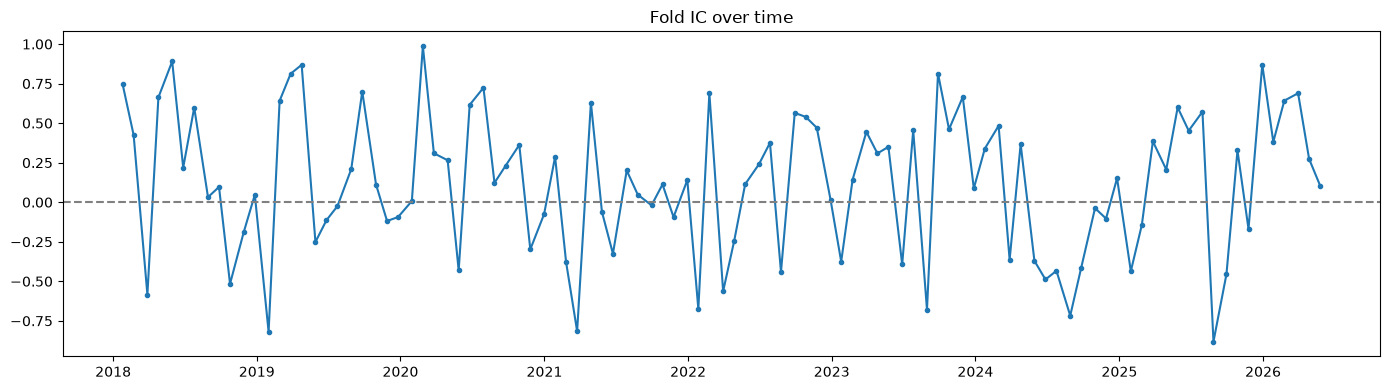


Excluding first 20 folds (small training size):
Mean IC: 0.1031, t-stat: 2.133


In [8]:
linear_results_df['test_start'] = pd.to_datetime(linear_results_df['test_start'])
linear_results_df = linear_results_df.sort_values('test_start')

# 1. IC vs training size - is instability just an early-fold small-sample problem?
train_sizes = [len(f['train_idx']) for f in folds]
linear_results_df['train_size'] = train_sizes
print(linear_results_df[['train_size','ic','mse']].corr())

# 2. worst and best folds - what dates/regimes were they?
print("\nWorst 5 folds (by IC):")
print(linear_results_df.nsmallest(5, 'ic')[['test_start','ic','mse','train_size']])
print("\nBest 5 folds (by IC):")
print(linear_results_df.nlargest(5, 'ic')[['test_start','ic','mse','train_size']])

# 3. IC over time - plot
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(linear_results_df['test_start'], linear_results_df['ic'], marker='o', markersize=3)
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Fold IC over time')
plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'miscellanous/linear_ic_over_time.png', dpi=100)
plt.show()

# 4. exclude first 20 folds (smallest training windows) and recompute
stable_folds = linear_results_df.iloc[20:]
print(f"\nExcluding first 20 folds (small training size):")
print(f"Mean IC: {stable_folds['ic'].mean():.4f}, t-stat: {stable_folds['ic'].mean()/(stable_folds['ic'].std()/np.sqrt(len(stable_folds))):.3f}")

                   ic  ic_spearman       mse  train_size
ic           1.000000     0.963787  0.090957   -0.061438
ic_spearman  0.963787     1.000000  0.084868   -0.072063
mse          0.090957     0.084868  1.000000   -0.188616
train_size  -0.061438    -0.072063 -0.188616    1.000000

Worst 5 folds (Spearman IC):
   test_start        ic  ic_spearman         mse  train_size
79 2024-08-29 -0.717330    -0.707018   21.783386        1968
48 2022-01-27 -0.674942    -0.696491   31.892978        1358
67 2023-08-31 -0.679362    -0.688338    6.690896        1734
38 2021-03-25 -0.815135    -0.687218  173.228462        1160
91 2025-08-28 -0.881169    -0.626200   57.697829        2205

Best 5 folds (Spearman IC):
   test_start        ic  ic_spearman         mse  train_size
25 2020-02-27  0.987124     0.989680  693.013510         905
14 2019-03-28  0.812364     0.889706   12.087403         690
4  2018-05-31  0.890653     0.866667    3.965572         495
15 2019-04-25  0.868807     0.864483   35.5972

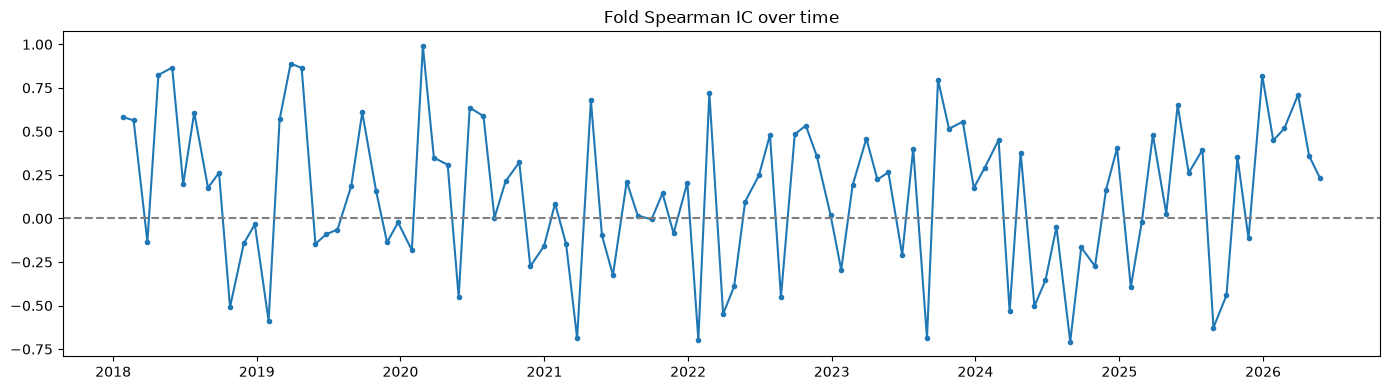


Excluding first 20 folds:
Mean Spearman IC: 0.1105, t-stat: 2.422


In [9]:
from scipy.stats import spearmanr

linear_results_df['ic_spearman'] = [
    spearmanr(p, y)[0] if len(y) > 2 else np.nan
    for p, y in zip(all_preds, all_y_test)
]

# 1. Pearson vs Spearman
print(linear_results_df[['ic','ic_spearman','mse','train_size']].corr())

# 2. worst and best folds
print("\nWorst 5 folds (Spearman IC):")
print(linear_results_df.nsmallest(5, 'ic_spearman')[['test_start','ic','ic_spearman','mse','train_size']])

print("\nBest 5 folds (Spearman IC):")
print(linear_results_df.nlargest(5, 'ic_spearman')[['test_start','ic','ic_spearman','mse','train_size']])

# 3. IC over time
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(linear_results_df['test_start'], linear_results_df['ic_spearman'], marker='o', markersize=3)
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Fold Spearman IC over time')
plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'miscellanous/linear_spearman_ic_over_time.png', dpi=100)
plt.show()

# 4. stable folds
stable = linear_results_df.iloc[20:]
print(f"\nExcluding first 20 folds:")
print(f"Mean Spearman IC: {stable['ic_spearman'].mean():.4f}, "
      f"t-stat: {stable['ic_spearman'].mean()/(stable['ic_spearman'].std()/np.sqrt(len(stable))):.3f}")

In [10]:
from joblib import Parallel, delayed
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

def run_fold(i, f):
    train = model_df.loc[f['train_idx']]
    test = model_df.loc[f['test_idx']]

    X_train = build_interaction_matrix(train, base_feats, interaction_feats)
    X_test = build_interaction_matrix(test, base_feats, interaction_feats)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train, y_test = train[target], test[target]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        alphas=np.logspace(-2, 1, 10),
        cv=3,
        max_iter=5000,
        n_jobs=1
    )
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)

    return {
        'fold': i,
        'test_start': f['test_start'],
        'ic_pearson': np.corrcoef(preds, y_test)[0,1] if len(y_test) > 2 else np.nan,
        'ic_spearman': spearmanr(preds, y_test)[0] if len(y_test) > 2 else np.nan,
        'mse': np.mean((preds - y_test)**2),
        'n': len(y_test),
        'n_nonzero_coef': np.sum(model.coef_ != 0),
        'alpha': model.alpha_,
        'l1_ratio': model.l1_ratio_,
        'preds': preds,
        'y_test': y_test.values
    }

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_fold)(i, f) for i, f in enumerate(folds)
)

preds_by_fold = {r['fold']: {'preds': r.pop('preds'), 'y_test': r.pop('y_test')} for r in results}
enet_results_df = pd.DataFrame(results)

print(enet_results_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"\nMean Pearson IC: {enet_results_df['ic_pearson'].mean():.4f}")
print(f"Mean Spearman IC: {enet_results_df['ic_spearman'].mean():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    4.2s


         ic_pearson  ic_spearman         mse  n_nonzero_coef
count  9.600000e+01    88.000000  101.000000      101.000000
mean   4.432315e-02     0.060213   24.298509       10.079208
std    5.669352e-01     0.574384   60.975199       10.044584
min   -9.411692e-01    -0.949867    0.298200        0.000000
25%   -4.539141e-01    -0.470824    5.320229        3.000000
50%    2.016928e-16     0.104781   10.539607        4.000000
75%    6.040549e-01     0.652764   21.037626       19.000000
max    9.936037e-01     0.987616  531.869869       40.000000

Mean Pearson IC: 0.0443
Mean Spearman IC: 0.0602


[Parallel(n_jobs=-1)]: Done  89 out of 101 | elapsed:    4.4s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 101 out of 101 | elapsed:    4.5s finished


# nifty_close in Confound - best linear model

In [11]:
# --- Candidate model specs ----------------------------------------------------
confounds = ['nifty_close']

feature_cols_clean = [c for c in feature_cols_model if c not in confounds]

stable_interactions = {
    'fii_stk_fut_net_pct': [3],
    'dii_opt_skew_pct': [0]
}

def build_stable_matrix(df):
    X = df[feature_cols_clean].copy()
    for feat, states in stable_interactions.items():
        for s in states:
            X[f'{feat}_x_state{s}'] = df[feat] * (df['hmm_state_v2'] == s).astype(int)
    return X

# --- Generic CV runner --------------------------------------------------------
def run_fold(builder):
    out = []
    for i, f in enumerate(folds):
        train = model_df.loc[f['train_idx']]
        test = model_df.loc[f['test_idx']]

        X_train = builder(train)
        X_test = builder(test).reindex(columns=X_train.columns, fill_value=0)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        y_train, y_test = train[target], test[target]

        model = ElasticNetCV(
            l1_ratio=[0.1,0.5,0.9,1.0],
            alphas=np.logspace(-2,1,10),
            cv=3,
            max_iter=10000,
            n_jobs=1
        )
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        if len(y_test) <= 2:
            ic_pearson = np.nan
            ic_spearman = np.nan
        elif np.allclose(preds, preds[0]) or np.allclose(y_test, y_test.iloc[0]):
            ic_pearson = np.nan
            ic_spearman = np.nan
        else:
            ic_pearson = np.corrcoef(preds, y_test)[0,1]
            ic_spearman = spearmanr(preds, y_test)[0]

        out.append({
            'fold': i,
            'test_start': f['test_start'],
            'ic_pearson': ic_pearson,
            'ic_spearman': ic_spearman,
            'mse': np.mean((preds-y_test)**2),
            'n_nonzero_coef': np.sum(model.coef_!=0)
        })

    df = pd.DataFrame(out)
    t = df['ic_pearson'].mean()/(df['ic_pearson'].std()/np.sqrt(df['ic_pearson'].count()))
    return df, t

# --- 1. Baseline --------------------------------------------------------------
baseline_df, baseline_t = run_fold(lambda d: d[feature_cols_model])

print("=== Baseline ===")
print(baseline_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {baseline_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {baseline_t:.3f}")

# --- 2. Baseline - confounds --------------------------------------------------
clean_df, clean_t = run_fold(lambda d: d[feature_cols_clean])

print("\n=== Baseline (minus confounds) ===")
print(clean_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {clean_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {clean_t:.3f}")

# --- 3. Stable interactions only ---------------------------------------------
stable_df, stable_t = run_fold(build_stable_matrix)

print("\n=== Baseline + stable interactions ===")
print(stable_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {stable_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {stable_t:.3f}")

# --- 4. Coefficient stability (stable interaction model) ----------------------
coef_names = build_stable_matrix(model_df).columns
selected_masks = []

for i, f in enumerate(folds):
    train = model_df.loc[f['train_idx']]

    X_train = build_stable_matrix(train).reindex(columns=coef_names, fill_value=0)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    model = ElasticNetCV(
        l1_ratio=[0.1,0.5,0.9,1.0],
        alphas=np.logspace(-2,1,10),
        cv=3,
        max_iter=10000,
        n_jobs=1
    )
    model.fit(X_train_s, train[target])
    selected_masks.append(model.coef_ != 0)

selected_masks = np.vstack(selected_masks)

selection_freq = pd.Series(
    selected_masks.mean(axis=0),
    index=coef_names
).sort_values(ascending=False)

print("\n=== Selection frequency ===")
print(selection_freq.head(15))
print(f"\nMean features selected per fold: {selected_masks.sum(axis=1).mean():.1f}")

overlaps = []
for i in range(len(selected_masks)-1):
    union = (selected_masks[i] | selected_masks[i+1]).sum()
    if union:
        overlaps.append((selected_masks[i] & selected_masks[i+1]).sum()/union)

print(f"Avg pairwise Jaccard: {np.mean(overlaps):.3f}")

=== Baseline ===
       ic_pearson  ic_spearman         mse  n_nonzero_coef
count   62.000000    62.000000  101.000000      101.000000
mean     0.163957     0.169394   24.169526        2.801980
std      0.504117     0.481699   60.916646        3.807939
min     -0.941169    -0.949867    0.430303        0.000000
25%     -0.189020    -0.181679    5.263114        0.000000
50%      0.209170     0.201994   10.539607        2.000000
75%      0.568152     0.572127   20.672540        4.000000
max      0.943965     0.937827  528.872287       14.000000
Mean Pearson IC: 0.1640
t-stat (Pearson): 2.561

=== Baseline (minus confounds) ===
       ic_pearson  ic_spearman         mse  n_nonzero_coef
count   61.000000    61.000000  101.000000      101.000000
mean     0.146771     0.151631   24.196609        3.158416
std      0.513018     0.489317   61.247813        5.043278
min     -0.941169    -0.949867    0.430303        0.000000
25%     -0.196523    -0.187867    4.891078        0.000000
50%      0.193

In [12]:
# Does market_cap_cr / num_trades predict fwd_ret independent of time trend?
import statsmodels.api as sm

for feat in ['market_cap_cr', 'num_trades']:
    df_check = model_df[[feat, target]].dropna().copy()
    df_check['time_idx'] = np.arange(len(df_check))
    
    # raw correlation with target
    raw_corr = df_check[feat].corr(df_check[target])
    
    # partial correlation after removing linear time trend from both
    resid_feat = sm.OLS(df_check[feat], sm.add_constant(df_check['time_idx'])).fit().resid
    resid_target = sm.OLS(df_check[target], sm.add_constant(df_check['time_idx'])).fit().resid
    partial_corr = np.corrcoef(resid_feat, resid_target)[0,1]
    
    print(f"{feat}: raw corr={raw_corr:.3f}, time-detrended partial corr={partial_corr:.3f}")

market_cap_cr: raw corr=-0.105, time-detrended partial corr=-0.173
num_trades: raw corr=-0.028, time-detrended partial corr=0.035


# nifty_close, market_cap_cr, num_trades all three in confounds

In [13]:
# --- Candidate model specs ----------------------------------------------------
confounds = [
    'nifty_close',
    'market_cap_cr',
    'num_trades'
]  # add market_cap_cr, num_trades later only if warranted

feature_cols_clean = [c for c in feature_cols_model if c not in confounds]

stable_interactions = {
    'fii_stk_fut_net_pct': [3],
    'dii_opt_skew_pct': [0]
}

def build_stable_matrix(df):
    X = df[feature_cols_clean].copy()
    for feat, states in stable_interactions.items():
        for s in states:
            X[f'{feat}_x_state{s}'] = df[feat] * (df['hmm_state_v2'] == s).astype(int)
    return X

# --- Generic CV runner --------------------------------------------------------
def run_fold(builder):
    out = []
    for i, f in enumerate(folds):
        train = model_df.loc[f['train_idx']]
        test = model_df.loc[f['test_idx']]

        X_train = builder(train)
        X_test = builder(test).reindex(columns=X_train.columns, fill_value=0)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        y_train, y_test = train[target], test[target]

        model = ElasticNetCV(
            l1_ratio=[0.1,0.5,0.9,1.0],
            alphas=np.logspace(-2,1,10),
            cv=3,
            max_iter=10000,
            n_jobs=1
        )
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        if len(y_test) <= 2:
            ic_pearson = np.nan
            ic_spearman = np.nan
        elif np.allclose(preds, preds[0]) or np.allclose(y_test, y_test.iloc[0]):
            ic_pearson = np.nan
            ic_spearman = np.nan
        else:
            ic_pearson = np.corrcoef(preds, y_test)[0,1]
            ic_spearman = spearmanr(preds, y_test)[0]

        out.append({
            'fold': i,
            'test_start': f['test_start'],
            'ic_pearson': ic_pearson,
            'ic_spearman': ic_spearman,
            'mse': np.mean((preds-y_test)**2),
            'n_nonzero_coef': np.sum(model.coef_!=0)
        })

    df = pd.DataFrame(out)
    t = df['ic_pearson'].mean()/(df['ic_pearson'].std()/np.sqrt(df['ic_pearson'].count()))
    return df, t

# --- 1. Baseline --------------------------------------------------------------
baseline_df, baseline_t = run_fold(lambda d: d[feature_cols_model])

print("=== Baseline ===")
print(baseline_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {baseline_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {baseline_t:.3f}")

# --- 2. Baseline - confounds --------------------------------------------------
clean_df, clean_t = run_fold(lambda d: d[feature_cols_clean])

print("\n=== Baseline (minus confounds) ===")
print(clean_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {clean_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {clean_t:.3f}")

# --- 3. Stable interactions only ---------------------------------------------
stable_df, stable_t = run_fold(build_stable_matrix)

print("\n=== Baseline + stable interactions ===")
print(stable_df[['ic_pearson','ic_spearman','mse','n_nonzero_coef']].describe())
print(f"Mean Pearson IC: {stable_df['ic_pearson'].mean():.4f}")
print(f"t-stat (Pearson): {stable_t:.3f}")

# --- 4. Coefficient stability (stable interaction model) ----------------------
coef_names = build_stable_matrix(model_df).columns
selected_masks = []

for i, f in enumerate(folds):
    train = model_df.loc[f['train_idx']]

    X_train = build_stable_matrix(train).reindex(columns=coef_names, fill_value=0)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    model = ElasticNetCV(
        l1_ratio=[0.1,0.5,0.9,1.0],
        alphas=np.logspace(-2,1,10),
        cv=3,
        max_iter=10000,
        n_jobs=1
    )
    model.fit(X_train_s, train[target])
    selected_masks.append(model.coef_ != 0)

selected_masks = np.vstack(selected_masks)

selection_freq = pd.Series(
    selected_masks.mean(axis=0),
    index=coef_names
).sort_values(ascending=False)

print("\n=== Selection frequency ===")
print(selection_freq.head(15))
print(f"\nMean features selected per fold: {selected_masks.sum(axis=1).mean():.1f}")

overlaps = []
for i in range(len(selected_masks)-1):
    union = (selected_masks[i] | selected_masks[i+1]).sum()
    if union:
        overlaps.append((selected_masks[i] & selected_masks[i+1]).sum()/union)

print(f"Avg pairwise Jaccard: {np.mean(overlaps):.3f}")

=== Baseline ===
       ic_pearson  ic_spearman         mse  n_nonzero_coef
count   62.000000    62.000000  101.000000      101.000000
mean     0.163957     0.169394   24.169526        2.801980
std      0.504117     0.481699   60.916646        3.807939
min     -0.941169    -0.949867    0.430303        0.000000
25%     -0.189020    -0.181679    5.263114        0.000000
50%      0.209170     0.201994   10.539607        2.000000
75%      0.568152     0.572127   20.672540        4.000000
max      0.943965     0.937827  528.872287       14.000000
Mean Pearson IC: 0.1640
t-stat (Pearson): 2.561

=== Baseline (minus confounds) ===
       ic_pearson  ic_spearman         mse  n_nonzero_coef
count   57.000000    57.000000  101.000000      101.000000
mean     0.082650     0.085370   24.150105        2.693069
std      0.501933     0.473461   61.412298        4.544761
min     -0.941169    -0.949867    0.430303        0.000000
25%     -0.292991    -0.304348    4.891078        0.000000
50%      0.123

In [14]:
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [15]:
def get_model(name):
    if name == 'rf':
        return RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=10, n_jobs=-1, random_state=42)
    if name == 'xgb':
        return xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.8,
                                 colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, n_jobs=-1, random_state=42)
    if name == 'lgbm':
        return lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.8,
                                  colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, n_jobs=-1, random_state=42, verbose=-1)
    if name == 'catboost':
        return CatBoostRegressor(iterations=300, depth=4, learning_rate=0.03, l2_leaf_reg=3.0,
                                  verbose=0, random_seed=42)

def run_fold_tree(i, f, model_name, feat_cols):
    train, test = model_df_hmm.loc[f['train_idx']], model_df_hmm.loc[f['test_idx']]
    X_train, X_test = train[feat_cols], test[feat_cols]
    y_train, y_test = train[target], test[target]

    model = get_model(model_name)

    if model_name == 'catboost' and 'hmm_state_v2' in feat_cols:
        cat_idx = feat_cols.index('hmm_state_v2')
        model.fit(
            X_train,
            y_train,
            cat_features=[cat_idx]
        )
    else:
        model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        'fold': i, 'test_start': f['test_start'],
        'ic_pearson': np.corrcoef(preds, y_test)[0,1] if len(y_test) > 2 else np.nan,
        'ic_spearman': spearmanr(preds, y_test)[0] if len(y_test) > 2 else np.nan,
        'rmse': np.sqrt(np.mean((preds - y_test)**2)),
        'dir_acc': (np.sign(preds) == np.sign(y_test)).mean(),
        'n': len(y_test)
    }

def run_experiment(model_name, feat_cols, label):
    results = Parallel(n_jobs=-1)(delayed(run_fold_tree)(i, f, model_name, feat_cols) for i, f in enumerate(folds))
    df = pd.DataFrame(results)
    t_stat = df['ic_pearson'].mean() / (df['ic_pearson'].std() / np.sqrt(df['ic_pearson'].count()))
    print(f"[{label}] IC={df['ic_pearson'].mean():.4f} (t={t_stat:.2f}) RankIC={df['ic_spearman'].mean():.4f} "
          f"RMSE={df['rmse'].mean():.4f} DirAcc={df['dir_acc'].mean():.4f}")
    return df

# --- one-hot encode HMM state ---
state_dummies = pd.get_dummies(
    model_df['hmm_state_v2'],
    prefix='hmm',
    dtype=np.uint8
)

model_df_hmm = pd.concat([model_df, state_dummies], axis=1)

# --- feature sets ---
feat_base = [c for c in feature_cols_model if c != 'nifty_close']  # your finalized linear-model feature list

feat_base_full = feat_base + [c for c in emission_raw if c not in feat_base]

# One-hot version (RF/XGB/LGBM)
feat_hmm_ohe = feat_base + list(state_dummies.columns)

# Native categorical version (CatBoost)
feat_hmm_cat = feat_base + ['hmm_state_v2']

# --- Phase 1: model comparison, no HMM/GARCH ---
all_results = {}
for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    all_results[f'{m}_base'] = run_experiment(m, feat_base_full, f'{m} baseline')

for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    all_results[f'{m}_without_emission_raw'] = run_experiment(m, feat_base, f'{m} without emission raw')

# --- Phase 2: model comparisons with HMM ---
for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    all_results[f'{m}_hmm_ohe'] = run_experiment(m, feat_hmm_ohe, f'{m} + HMM (OHE)')

for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    all_results[f'{m}_hmm_cat'] = run_experiment(m, feat_hmm_cat, f'{m} + HMM (Single Col)')

[rf baseline] IC=0.0813 (t=1.60) RankIC=0.1242 RMSE=4.5302 DirAcc=0.5122
[xgb baseline] IC=0.1791 (t=4.28) RankIC=0.1839 RMSE=4.4121 DirAcc=0.5364
[lgbm baseline] IC=0.1222 (t=2.80) RankIC=0.1171 RMSE=4.6480 DirAcc=0.5339
[catboost baseline] IC=0.1631 (t=3.60) RankIC=0.1564 RMSE=4.2098 DirAcc=0.5593
[rf without emission raw] IC=0.1049 (t=2.09) RankIC=0.1257 RMSE=4.5094 DirAcc=0.5122
[xgb without emission raw] IC=0.1728 (t=3.84) RankIC=0.1671 RMSE=4.3853 DirAcc=0.5409
[lgbm without emission raw] IC=0.1343 (t=2.96) RankIC=0.1289 RMSE=4.5909 DirAcc=0.5262
[catboost without emission raw] IC=0.1781 (t=3.84) RankIC=0.1635 RMSE=4.1934 DirAcc=0.5509
[rf + HMM (OHE)] IC=0.0777 (t=1.57) RankIC=0.0878 RMSE=4.5062 DirAcc=0.5277
[xgb + HMM (OHE)] IC=0.1496 (t=3.55) RankIC=0.1438 RMSE=4.3428 DirAcc=0.5530
[lgbm + HMM (OHE)] IC=0.1297 (t=2.96) RankIC=0.1183 RMSE=4.4983 DirAcc=0.5416
[catboost + HMM (OHE)] IC=0.1607 (t=3.58) RankIC=0.1682 RMSE=4.1545 DirAcc=0.5547
[rf + HMM (Single Col)] IC=0.0851 (t=

In [16]:
# Store feature sets used by each experiment
feature_sets = {}

for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    feature_sets[f'{m}_base'] = feat_base_full
    feature_sets[f'{m}_without_emission_raw'] = feat_base
    feature_sets[f'{m}_hmm_ohe'] = feat_hmm_ohe
    feature_sets[f'{m}_hmm_cat'] = feat_hmm_cat

def fit_full_model(model_name, feat_cols):
    model = get_model(model_name)

    X = model_df_hmm[feat_cols]
    y = model_df_hmm[target]

    if model_name == 'catboost' and 'hmm_state_v2' in feat_cols:
        cat_idx = feat_cols.index('hmm_state_v2')
        model.fit(X, y, cat_features=[cat_idx])
    else:
        model.fit(X, y)

    return model


for exp_name, feat_cols in feature_sets.items():

    model_name = exp_name.split('_')[0]  # rf/xgb/lgbm/catboost

    print("\n" + "=" * 80)
    print(exp_name.upper())
    print("=" * 80)

    model = fit_full_model(model_name, feat_cols)

    imp = (
        pd.Series(model.feature_importances_, index=feat_cols)
        .sort_values(ascending=False)
    )

    print("\nTop 15 features")
    print(imp.head(15))

    emission_present = [c for c in emission_raw if c in imp.index]

    if emission_present:
        print("\nHMM emission features")
        print(imp.loc[emission_present].sort_values(ascending=False))

    if 'hmm_state_v2' in imp.index:
        print("\nHMM state importance")
        print(imp.loc[['hmm_state_v2']])

    hmm_ohe_cols = [c for c in imp.index if c.startswith('hmm_')]
    if hmm_ohe_cols:
        print("\nOne-hot HMM state importance")
        print(imp.loc[hmm_ohe_cols].sort_values(ascending=False))


RF_BASE

Top 15 features
market_cap_cr            0.216308
underlying_daily_vol     0.126843
client_fut_net_pct       0.077837
dii_fut_net_pct          0.073148
dii_opt_skew_pct         0.062083
applicable_daily_vol     0.043551
futures_daily_vol        0.040094
fii_pe_net_pct           0.031093
vix_realized_spread      0.027327
client_opt_skew_pct      0.027248
fii_stk_fut_net_pct      0.026303
fii_client_divergence    0.026165
vix_chg_5d               0.025518
pro_opt_skew_pct         0.025201
fii_stats_oi_net_cr      0.024800
dtype: float64

HMM emission features
underlying_daily_vol     0.126843
client_opt_skew_pct      0.027248
vix_close                0.023234
max_pain_dist_pct        0.021309
price_band_hits          0.015196
basis_chg_5d             0.000916
fii_stats_fut_net_pct    0.000210
dtype: float64

RF_WITHOUT_EMISSION_RAW

Top 15 features
market_cap_cr             0.240647
applicable_daily_vol      0.108942
futures_daily_vol         0.098008
client_fut_net_pct        

# GARCH addition

In [17]:
from arch import arch_model

# --- daily returns, once ---
if 'nifty_ret_1d' not in model_df.columns:
    model_df['nifty_ret_1d'] = np.log(model_df['nifty_close']).diff()

def compute_garch_features(train_idx, test_idx):
    train_ret = model_df.loc[train_idx, 'nifty_ret_1d'].dropna() * 100

    try:
        am = arch_model(train_ret, vol='Garch', p=1, q=1, dist='t')
        res = am.fit(disp='off')
    except Exception:
        nan_train = pd.DataFrame(np.nan, index=train_idx, columns=['garch_sigma','garch_sigma_change'])
        nan_test = nan_train.reindex(test_idx)
        return nan_train, nan_test

    sigma_train = res.conditional_volatility / 100
    sigma_change_train = sigma_train.diff()

    train_feat = pd.DataFrame({
        'garch_sigma': sigma_train.values,
        'garch_sigma_change': sigma_change_train.values
    }, index=train_ret.index)

    fcast = res.forecast(horizon=len(test_idx), reindex=False)
    sigma_path = np.sqrt(fcast.variance.values[-1]) / 100

    test_feat = pd.DataFrame({
        'garch_sigma': sigma_path,
        'garch_sigma_change': np.diff(sigma_path, prepend=sigma_train.iloc[-1])
    }, index=test_idx[:len(sigma_path)])

    return train_feat, test_feat

garch_features_by_fold = {}
for i, f in enumerate(folds):
    garch_features_by_fold[i] = compute_garch_features(f['train_idx'], f['test_idx'])

def run_fold_tree_garch(i, f, model_name, feat_cols, garch_cols=None):
    train, test = model_df_hmm.loc[f['train_idx']].copy(), model_df_hmm.loc[f['test_idx']].copy()

    feat_garch_cols = feat_cols.copy()

    if garch_cols:
        train_feat, test_feat = garch_features_by_fold[i]
        train = train.join(train_feat)
        test = test.join(test_feat)
        train = train.dropna(subset=garch_cols)  # GARCH fit drops leading NaN return rows
        feat_garch_cols += garch_cols

    X_train, X_test = train[feat_garch_cols], test[feat_garch_cols]
    y_train, y_test = train[target], test[target]

    if len(X_train) < 30 or len(X_test) < 2:
        return None

    model = get_model(model_name)

    if model_name == 'catboost' and 'hmm_state_v2' in feat_garch_cols:
        cat_idx = feat_garch_cols.index('hmm_state_v2')
        model.fit(
            X_train,
            y_train,
            cat_features=[cat_idx]
        )
    else:
        model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        'fold': i, 'test_start': f['test_start'],
        'ic_pearson': np.corrcoef(preds, y_test)[0,1] if len(y_test) > 2 else np.nan,
        'ic_spearman': spearmanr(preds, y_test)[0] if len(y_test) > 2 else np.nan,
        'rmse': np.sqrt(np.mean((preds - y_test)**2)),
        'dir_acc': (np.sign(preds) == np.sign(y_test)).mean(),
    }

def run_experiment_garch(model_name, feat_cols, label, garch_cols=None):
    results = Parallel(n_jobs=-1)(
        delayed(run_fold_tree_garch)(i, f, model_name, feat_cols, garch_cols) for i, f in enumerate(folds)
    )
    df = pd.DataFrame([r for r in results if r is not None])
    t_stat = df['ic_pearson'].mean() / (df['ic_pearson'].std() / np.sqrt(df['ic_pearson'].count()))
    print(f"[{label}] IC={df['ic_pearson'].mean():.4f} (t={t_stat:.2f}) RankIC={df['ic_spearman'].mean():.4f} "
          f"RMSE={df['rmse'].mean():.4f} DirAcc={df['dir_acc'].mean():.4f}  (n_folds={len(df)})")
    return df

In [18]:
# --- full grid, all four models ---
sigma_only  = ['garch_sigma']
sigma_delta = ['garch_sigma', 'garch_sigma_change']

feature_sets_garch = {}

for m in ['rf', 'xgb', 'lgbm', 'catboost']:

    hmm_feats = feat_hmm_cat if m == 'catboost' else feat_hmm_ohe

    # -----------------------------
    # Full baseline (includes emission_raw)
    # -----------------------------
    feature_sets_garch[f'{m}_base_full'] = {'feat_cols': feat_base_full, 'garch_cols': None}

    feature_sets_garch[f'{m}_base_full_sigma'] = {'feat_cols': feat_base_full, 'garch_cols': sigma_only}

    feature_sets_garch[f'{m}_base_full_sigma_delta'] = {'feat_cols': feat_base_full, 'garch_cols': sigma_delta}

    # -----------------------------
    # Reduced baseline (without emission_raw)
    # -----------------------------
    feature_sets_garch[f'{m}_base'] = {'feat_cols': feat_base, 'garch_cols': None}

    feature_sets_garch[f'{m}_base_sigma'] = {'feat_cols': feat_base, 'garch_cols': sigma_only}

    feature_sets_garch[f'{m}_base_sigma_delta'] = {'feat_cols': feat_base, 'garch_cols': sigma_delta}

    # -----------------------------
    # HMM experiments
    # -----------------------------
    feature_sets_garch[f'{m}_hmm'] = {'feat_cols': hmm_feats, 'garch_cols': None}

    feature_sets_garch[f'{m}_hmm_sigma'] = {'feat_cols': hmm_feats, 'garch_cols': sigma_only}

    feature_sets_garch[f'{m}_hmm_sigma_delta'] = {'feat_cols': hmm_feats, 'garch_cols': sigma_delta}

In [19]:
garch_results = {}

for m in ['rf', 'xgb', 'lgbm', 'catboost']:
    hmm_feats = feat_hmm_cat if m == 'catboost' else feat_hmm_ohe

    garch_results[f'{m}_base_full'] = run_experiment_garch(m, feat_base_full, f'{m} baseline (full)')
    garch_results[f'{m}_base_full_sigma'] = run_experiment_garch(m, feat_base_full, f'{m} baseline (full) + sigma', sigma_only)
    garch_results[f'{m}_base_full_sigma_delta'] = run_experiment_garch(m, feat_base_full, f'{m} baseline (full) + sigma + delta', sigma_delta)

    garch_results[f'{m}_base'] = run_experiment_garch(m, feat_base, f'{m} baseline')
    garch_results[f'{m}_base_sigma'] = run_experiment_garch(m, feat_base, f'{m} + sigma', sigma_only)
    garch_results[f'{m}_base_sigma_delta'] = run_experiment_garch(m, feat_base, f'{m} + sigma + delta', sigma_delta)

    garch_results[f'{m}_hmm'] = run_experiment_garch(m, hmm_feats, f'{m} + HMM')
    garch_results[f'{m}_hmm_sigma'] = run_experiment_garch(m, hmm_feats, f'{m} + HMM + sigma', sigma_only)
    garch_results[f'{m}_hmm_sigma_delta'] = run_experiment_garch(m, hmm_feats, f'{m} + HMM + sigma + delta', sigma_delta)

[rf baseline (full)] IC=0.0813 (t=1.60) RankIC=0.1242 RMSE=4.5302 DirAcc=0.5122  (n_folds=101)
[rf baseline (full) + sigma] IC=0.0807 (t=1.58) RankIC=0.1157 RMSE=4.5163 DirAcc=0.5137  (n_folds=101)
[rf baseline (full) + sigma + delta] IC=0.0684 (t=1.33) RankIC=0.0997 RMSE=4.5207 DirAcc=0.5121  (n_folds=101)
[rf baseline] IC=0.1049 (t=2.09) RankIC=0.1257 RMSE=4.5094 DirAcc=0.5122  (n_folds=101)
[rf + sigma] IC=0.1149 (t=2.31) RankIC=0.1309 RMSE=4.5128 DirAcc=0.5096  (n_folds=101)
[rf + sigma + delta] IC=0.1086 (t=2.17) RankIC=0.1225 RMSE=4.5170 DirAcc=0.5073  (n_folds=101)
[rf + HMM] IC=0.0777 (t=1.57) RankIC=0.0878 RMSE=4.5062 DirAcc=0.5277  (n_folds=101)
[rf + HMM + sigma] IC=0.0844 (t=1.72) RankIC=0.1038 RMSE=4.5008 DirAcc=0.5219  (n_folds=101)
[rf + HMM + sigma + delta] IC=0.0791 (t=1.60) RankIC=0.0891 RMSE=4.5205 DirAcc=0.5229  (n_folds=101)
[xgb baseline (full)] IC=0.1791 (t=4.28) RankIC=0.1839 RMSE=4.4121 DirAcc=0.5364  (n_folds=101)
[xgb baseline (full) + sigma] IC=0.1712 (t=3.9

In [20]:
# Reconstruct GARCH sigma aligned to model_df
garch_sigma = pd.Series(index=model_df.index, dtype=float)

for train_feat, test_feat in garch_features_by_fold.values():
    garch_sigma.loc[test_feat.index] = test_feat['garch_sigma']

# Check correlations
corr_check = model_df[
    ['futures_daily_vol', 'applicable_daily_vol', 'underlying_daily_vol']
].corrwith(garch_sigma)

print(corr_check)

futures_daily_vol       0.494492
applicable_daily_vol    0.494541
underlying_daily_vol    0.495614
dtype: float64


In [21]:
garch_sigma_change = pd.Series(index=model_df.index, dtype=float)

for train_feat, test_feat in garch_features_by_fold.values():
    garch_sigma_change.loc[test_feat.index] = test_feat['garch_sigma_change']

print(model_df[
    ['futures_daily_vol', 'applicable_daily_vol', 'underlying_daily_vol']
].corrwith(garch_sigma_change))

futures_daily_vol      -0.321004
applicable_daily_vol   -0.320949
underlying_daily_vol   -0.319066
dtype: float64


In [22]:
from scipy.stats import wilcoxon

cb_df = garch_results['catboost_base_sigma'] 
xgb_df = garch_results['xgb_base_sigma_delta']

merged = cb_df.merge(xgb_df, on='fold', suffixes=('_cb', '_xgb'))
diff = merged['ic_pearson_cb'] - merged['ic_pearson_xgb']
stat, p = wilcoxon(diff)
print(f"Wilcoxon signed-rank: stat={stat:.2f}, p={p:.4f}, mean diff={diff.mean():.4f}")

Wilcoxon signed-rank: stat=2573.00, p=0.9932, mean diff=0.0106


e:\Projects\embR\embRenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


35 42
{'fii_stats_fut_net_pct', 'client_opt_skew_pct', 'underlying_daily_vol', 'vix_close', 'max_pain_dist_pct', 'price_band_hits', 'basis_chg_5d'}


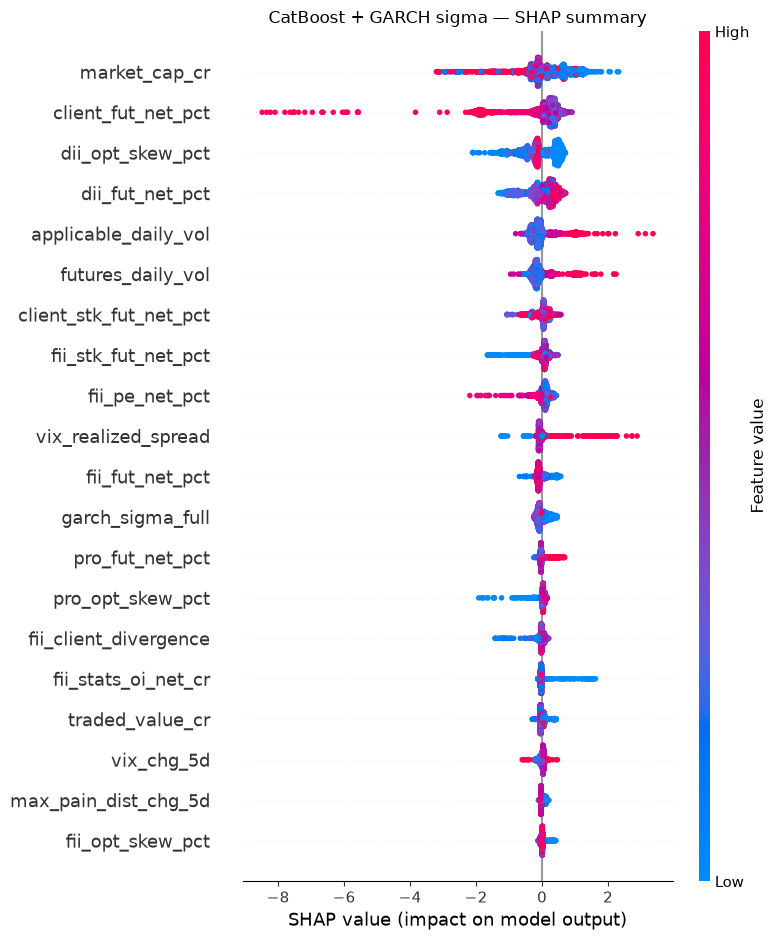

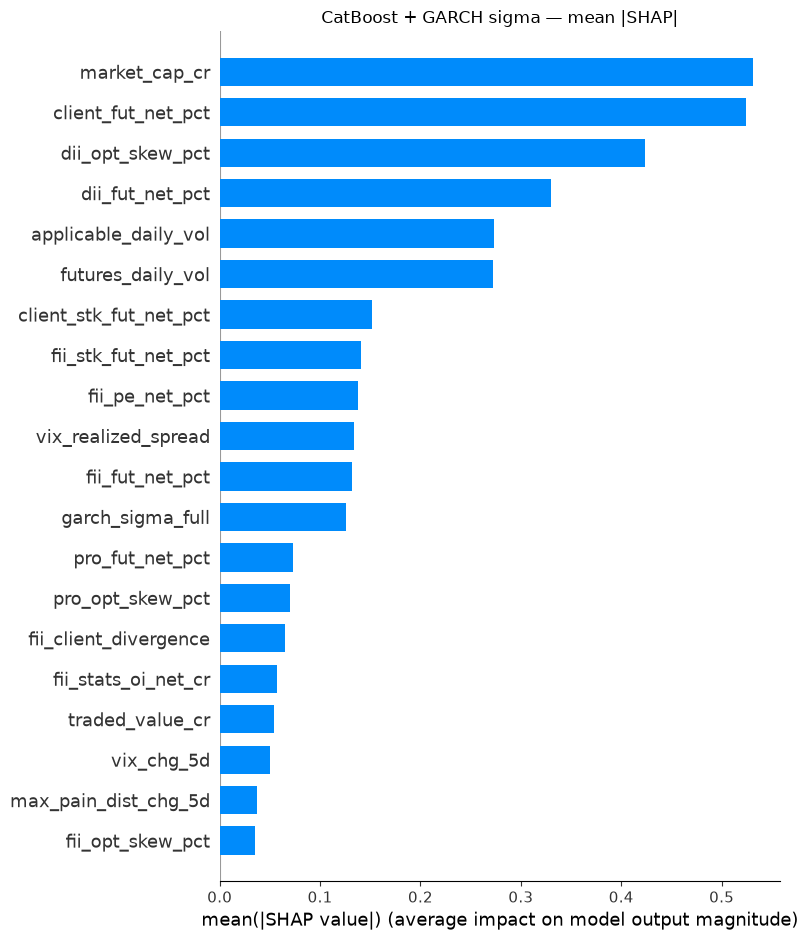

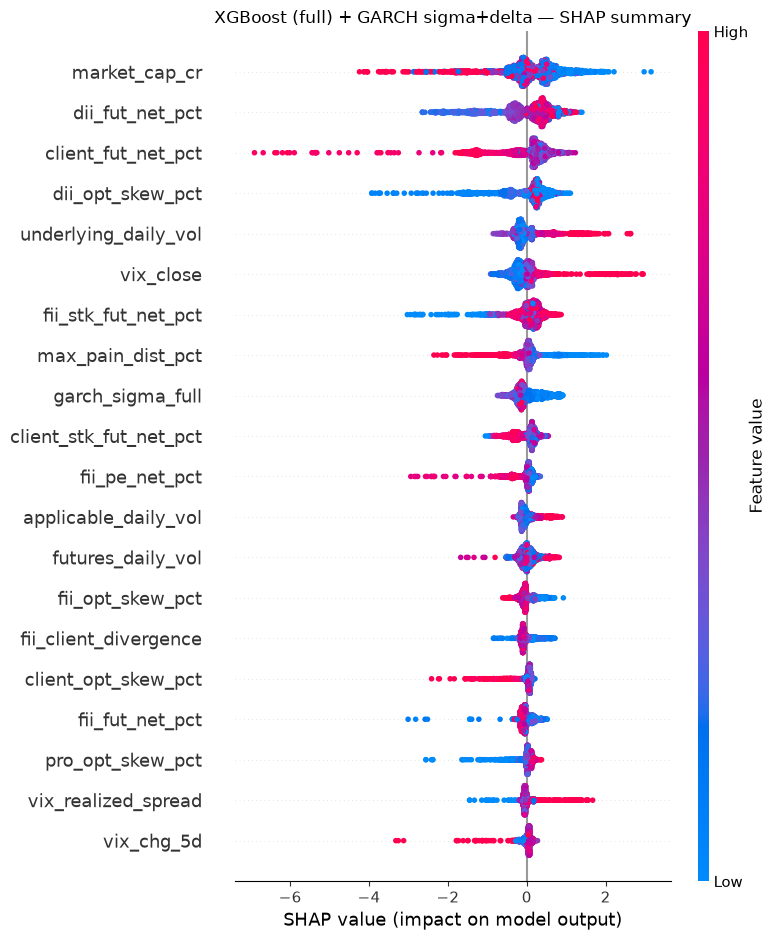

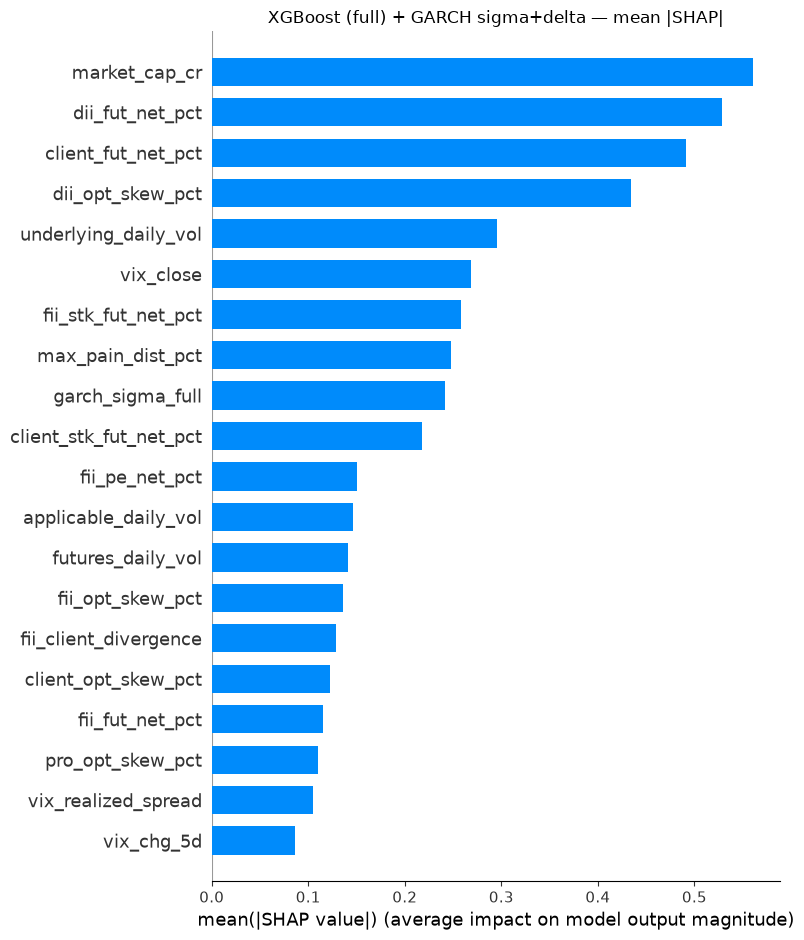

                        CatBoost   XGBoost  CB_rank  XGB_rank
market_cap_cr           0.531544  0.560593      1.0       1.0
client_fut_net_pct      0.524454  0.491598      2.0       3.0
dii_opt_skew_pct        0.423409  0.434008      3.0       4.0
dii_fut_net_pct         0.329688  0.528112      4.0       2.0
applicable_daily_vol    0.272932  0.146620      5.0      12.0
futures_daily_vol       0.271877  0.140677      6.0      13.0
client_stk_fut_net_pct  0.152082  0.217490      7.0      10.0
fii_stk_fut_net_pct     0.141121  0.258351      8.0       7.0
fii_pe_net_pct          0.137744  0.150895      9.0      11.0
vix_realized_spread     0.134004  0.104536     10.0      19.0
fii_fut_net_pct         0.131680  0.115072     11.0      17.0
garch_sigma_full        0.125329  0.241796     12.0       9.0
pro_fut_net_pct         0.072674  0.060304     13.0      25.0
pro_opt_skew_pct        0.069633  0.109749     14.0      18.0
fii_client_divergence   0.064599  0.128314     15.0      15.0
fii_stat

In [23]:
import shap

# --- 0. sanity check feature sets before anything else ---
print(len(feat_base), len(feat_base_full))
print(set(feat_base_full) - set(feat_base))

# --- 1. fit GARCH once on full series, use temp column names to avoid clobbering walk-forward cols ---
full_ret = model_df['nifty_ret_1d'].dropna() * 100
am_full = arch_model(full_ret, vol='Garch', p=1, q=1, dist='t')
res_full = am_full.fit(disp='off')

model_df.loc[full_ret.index, 'garch_sigma_full'] = res_full.conditional_volatility / 100
model_df.loc[full_ret.index, 'garch_sigma_change_full'] = model_df.loc[full_ret.index, 'garch_sigma_full'].diff()

# --- 2. exact feature sets matching the reported experiments ---
feat_cb  = feat_base + ['garch_sigma_full']                                   # catboost_base_sigma
feat_xgb = feat_base_full + ['garch_sigma_full', 'garch_sigma_change_full']   # xgb_base_full_sigma_delta

# --- 3. confirm get_model returns regressors ---
assert isinstance(get_model('catboost'), CatBoostRegressor)
assert isinstance(get_model('xgb'), xgb.XGBRegressor)

# --- 4. fit + SHAP: CatBoost ---
df_cb = model_df.dropna(subset=feat_cb + [target])
X_cb, y_cb = df_cb[feat_cb], df_cb[target]

cb_model = get_model('catboost')
cb_model.fit(X_cb, y_cb)

explainer_cb = shap.TreeExplainer(cb_model)
shap_values_cb = explainer_cb.shap_values(X_cb)
cb_shap_df = pd.DataFrame(shap_values_cb, columns=X_cb.columns)

shap.summary_plot(shap_values_cb, X_cb, show=False, max_display=20)
plt.title('CatBoost + GARCH sigma — SHAP summary'); plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'shap/catboost_sigma.png', dpi=150); plt.show()

shap.summary_plot(shap_values_cb, X_cb, plot_type='bar', show=False, max_display=20)
plt.title('CatBoost + GARCH sigma — mean |SHAP|'); plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'shap/catboost_sigma_bar.png', dpi=150); plt.show()

# --- 5. fit + SHAP: XGBoost ---
df_xgb = model_df.dropna(subset=feat_xgb + [target])
X_xgb, y_xgb = df_xgb[feat_xgb], df_xgb[target]

xgb_model = get_model('xgb')
xgb_model.fit(X_xgb, y_xgb)

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_xgb)
xgb_shap_df = pd.DataFrame(shap_values_xgb, columns=X_xgb.columns)

shap.summary_plot(shap_values_xgb, X_xgb, show=False, max_display=20)
plt.title('XGBoost (full) + GARCH sigma+delta — SHAP summary'); plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'shap/xgb_sigma_delta.png', dpi=150); plt.show()

shap.summary_plot(shap_values_xgb, X_xgb, plot_type='bar', show=False, max_display=20)
plt.title('XGBoost (full) + GARCH sigma+delta — mean |SHAP|'); plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'shap/xgb_sigma_delta_bar.png', dpi=150); plt.show()

# --- 6. comparison table ---
imp_cb  = pd.Series(np.abs(shap_values_cb).mean(axis=0), index=feat_cb)
imp_xgb = pd.Series(np.abs(shap_values_xgb).mean(axis=0), index=feat_xgb)

comparison = pd.concat([imp_cb.rename('CatBoost'), imp_xgb.rename('XGBoost')], axis=1).fillna(0)
comparison['CB_rank']  = comparison['CatBoost'].rank(ascending=False, method='min')
comparison['XGB_rank'] = comparison['XGBoost'].rank(ascending=False, method='min')
comparison = comparison.sort_values('CB_rank')

print(comparison.head(20))
print(f"\ngarch_sigma_full rank — CatBoost: {int(comparison.loc['garch_sigma_full','CB_rank'])} / {len(comparison)}")
print(f"garch_sigma_full rank — XGBoost: {int(comparison.loc['garch_sigma_full','XGB_rank'])} / {len(comparison)}")

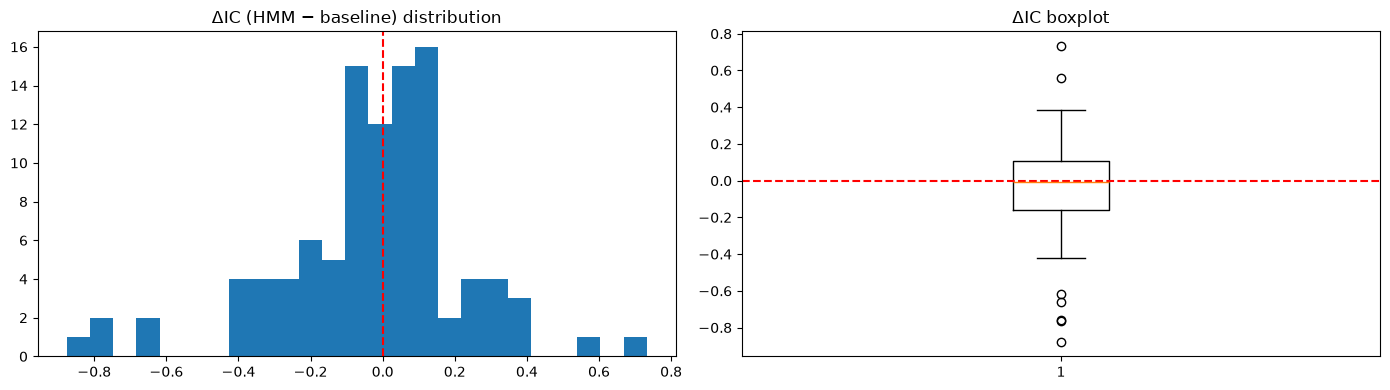

Comparing xgb_base and xgb_hmm_ohe
    test_start  delta_ic
48  2022-01-27 -0.876260
91  2025-08-28 -0.761933
4   2018-05-31 -0.756811
37  2021-02-25 -0.658788
81  2024-10-31 -0.618953
59  2022-12-29 -0.419560
82  2024-11-28 -0.408971
78  2024-07-25 -0.405933
65  2023-06-29 -0.399444
100 2026-05-26 -0.333442
   test_start  delta_ic
68 2023-09-28  0.279450
8  2018-09-27  0.294505
69 2023-10-26  0.313786
18 2019-07-25  0.329882
9  2018-10-25  0.337803
97 2026-02-24  0.365557
23 2019-12-26  0.382056
51 2022-04-28  0.385954
96 2026-01-27  0.559799
95 2025-12-30  0.732469

Mean ΔIC: -0.02955
% folds where HMM helped: 48.51%


In [25]:
# --- A. fold-wise paired ΔIC ---

base = 'xgb_base'
hmm = 'xgb_hmm_ohe'

baseline_df = all_results[base]
hmm_df      = all_results[hmm] 

merged = baseline_df.merge(hmm_df, on='fold', suffixes=('_base', '_cmp'))

merged['delta_ic'] = merged['ic_pearson_cmp'] - merged['ic_pearson_base']
merged['test_start'] = merged['test_start_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(merged['delta_ic'], bins=25)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('ΔIC (HMM − baseline) distribution')

axes[1].boxplot(merged['delta_ic'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('ΔIC boxplot')

plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'hmm_compare/delta_ic_{base}_{hmm}.png', dpi=100)
plt.show()

print(f"Comparing {base} and {hmm}")

print(merged[['test_start','delta_ic']].sort_values('delta_ic').head(10))
print(merged[['test_start','delta_ic']].sort_values('delta_ic').tail(10))

print(f"\nMean ΔIC: {merged['delta_ic'].mean():.5f}")
print(f"% folds where HMM helped: {(merged['delta_ic'] > 0).mean():.2%}")

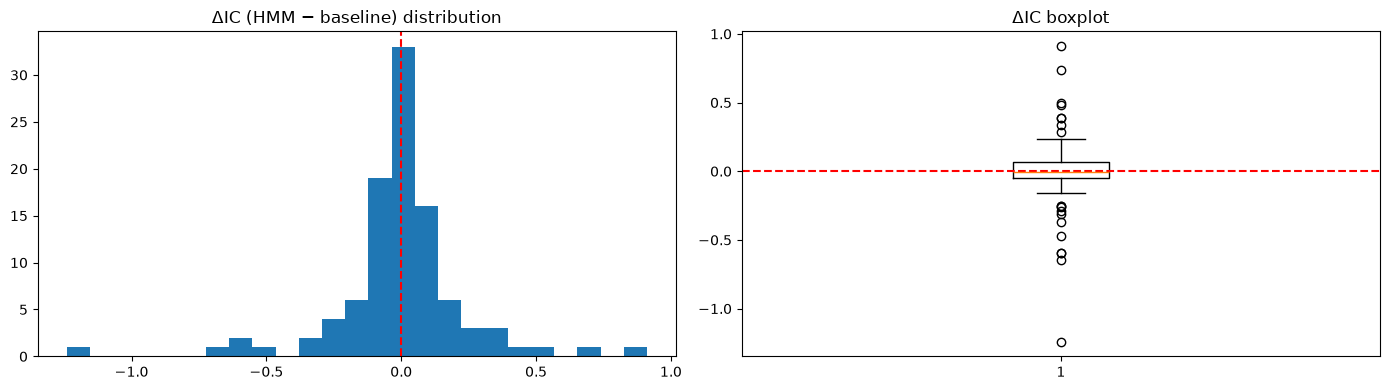

Comparing rf_base and rf_hmm_ohe
   test_start  delta_ic
91 2025-08-28 -1.240157
48 2022-01-27 -0.649562
93 2025-10-28 -0.598238
44 2021-09-30 -0.597172
4  2018-05-31 -0.473795
82 2024-11-28 -0.368823
74 2024-03-28 -0.308650
50 2022-03-31 -0.286578
27 2020-04-30 -0.259623
34 2020-11-26 -0.255570
   test_start  delta_ic
70 2023-11-30  0.224989
96 2026-01-27  0.237827
18 2019-07-25  0.285269
64 2023-05-25  0.337945
97 2026-02-24  0.387598
76 2024-05-30  0.388581
8  2018-09-27  0.479588
83 2024-12-26  0.499483
69 2023-10-26  0.733593
98 2026-03-31  0.911039

Mean ΔIC: -0.00352
% folds where HMM helped: 47.52%


In [26]:
# --- A. fold-wise paired ΔIC ---

base = 'rf_base'
hmm = 'rf_hmm_ohe'

baseline_df = all_results[base]
hmm_df      = all_results[hmm] 

merged = baseline_df.merge(hmm_df, on='fold', suffixes=('_base', '_cmp'))

merged['delta_ic'] = merged['ic_pearson_cmp'] - merged['ic_pearson_base']
merged['test_start'] = merged['test_start_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(merged['delta_ic'], bins=25)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('ΔIC (HMM − baseline) distribution')

axes[1].boxplot(merged['delta_ic'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('ΔIC boxplot')

plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'hmm_compare/delta_ic_{base}_{hmm}.png', dpi=100)
plt.show()

print(f"Comparing {base} and {hmm}")

print(merged[['test_start','delta_ic']].sort_values('delta_ic').head(10))
print(merged[['test_start','delta_ic']].sort_values('delta_ic').tail(10))

print(f"\nMean ΔIC: {merged['delta_ic'].mean():.5f}")
print(f"% folds where HMM helped: {(merged['delta_ic'] > 0).mean():.2%}")

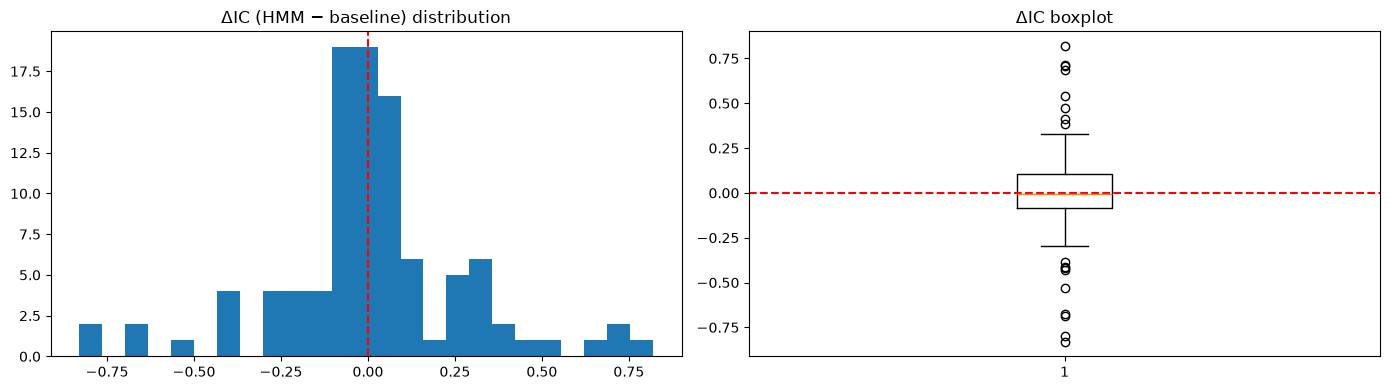

Comparing lgbm_base and lgbm_hmm_ohe
    test_start  delta_ic
4   2018-05-31 -0.829517
48  2022-01-27 -0.796233
37  2021-02-25 -0.686575
91  2025-08-28 -0.674737
2   2018-03-29 -0.530632
100 2026-05-26 -0.432679
82  2024-11-28 -0.418921
12  2019-01-31 -0.411137
49  2022-02-24 -0.387355
10  2018-11-29 -0.294284
   test_start  delta_ic
76 2024-05-30  0.323238
59 2022-12-29  0.330317
17 2019-06-27  0.385612
86 2025-03-27  0.410293
65 2023-06-29  0.472334
68 2023-09-28  0.539146
98 2026-03-31  0.686775
96 2026-01-27  0.708956
92 2025-09-30  0.712919
70 2023-11-30  0.818895

Mean ΔIC: 0.00745
% folds where HMM helped: 49.50%


In [27]:
# --- A. fold-wise paired ΔIC ---

base = 'lgbm_base'
hmm = 'lgbm_hmm_ohe'

baseline_df = all_results[base]
hmm_df      = all_results[hmm] 

merged = baseline_df.merge(hmm_df, on='fold', suffixes=('_base', '_cmp'))

merged['delta_ic'] = merged['ic_pearson_cmp'] - merged['ic_pearson_base']
merged['test_start'] = merged['test_start_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(merged['delta_ic'], bins=25)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('ΔIC (HMM − baseline) distribution')

axes[1].boxplot(merged['delta_ic'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('ΔIC boxplot')

plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'hmm_compare/delta_ic_{base}_{hmm}.png', dpi=100)
plt.show()

print(f"Comparing {base} and {hmm}")

print(merged[['test_start','delta_ic']].sort_values('delta_ic').head(10))
print(merged[['test_start','delta_ic']].sort_values('delta_ic').tail(10))

print(f"\nMean ΔIC: {merged['delta_ic'].mean():.5f}")
print(f"% folds where HMM helped: {(merged['delta_ic'] > 0).mean():.2%}")

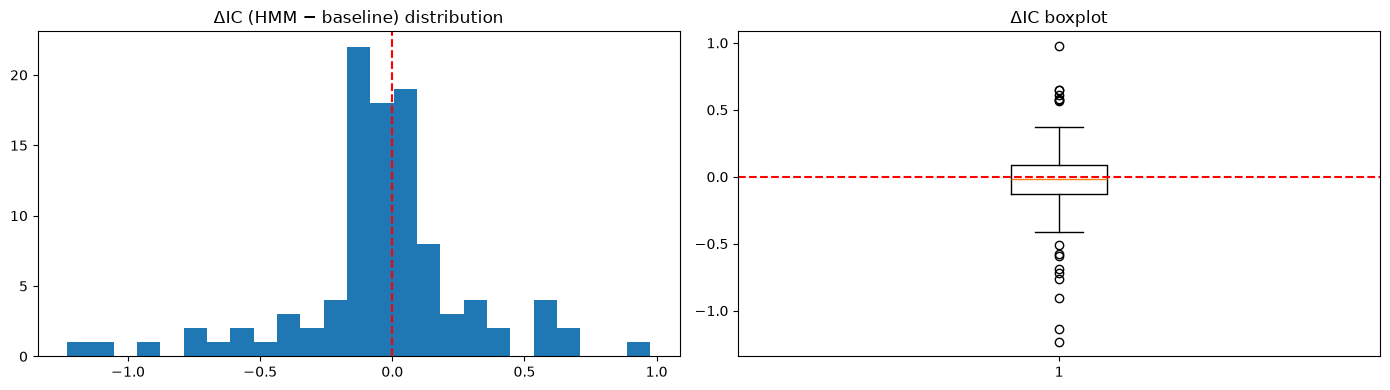

Comparing catboost_base and catboost_hmm_cat
   test_start  delta_ic
67 2023-08-31 -1.231190
48 2022-01-27 -1.138289
61 2023-02-23 -0.904971
37 2021-02-25 -0.763985
91 2025-08-28 -0.717332
76 2024-05-30 -0.689639
12 2019-01-31 -0.593108
40 2021-05-27 -0.573987
4  2018-05-31 -0.512063
50 2022-03-31 -0.412678
   test_start  delta_ic
39 2021-04-29  0.353942
18 2019-07-25  0.358419
71 2023-12-28  0.369849
26 2020-03-26  0.567346
96 2026-01-27  0.573704
97 2026-02-24  0.579288
70 2023-11-30  0.610524
90 2025-07-31  0.647892
98 2026-03-31  0.650351
68 2023-09-28  0.976074

Mean ΔIC: -0.03695
% folds where HMM helped: 45.54%


In [28]:
# --- A. fold-wise paired ΔIC ---

base = 'catboost_base'
hmm = 'catboost_hmm_cat'

baseline_df = all_results[base]
hmm_df      = all_results[hmm] 

merged = baseline_df.merge(hmm_df, on='fold', suffixes=('_base', '_cmp'))

merged['delta_ic'] = merged['ic_pearson_cmp'] - merged['ic_pearson_base']
merged['test_start'] = merged['test_start_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(merged['delta_ic'], bins=25)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('ΔIC (HMM − baseline) distribution')

axes[1].boxplot(merged['delta_ic'])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('ΔIC boxplot')

plt.tight_layout()
plt.savefig(RESEARCH_PLOTS_20D / 'hmm_compare/delta_ic_{base}_{hmm}.png', dpi=100)
plt.show()

print(f"Comparing {base} and {hmm}")

print(merged[['test_start','delta_ic']].sort_values('delta_ic').head(10))
print(merged[['test_start','delta_ic']].sort_values('delta_ic').tail(10))

print(f"\nMean ΔIC: {merged['delta_ic'].mean():.5f}")
print(f"% folds where HMM helped: {(merged['delta_ic'] > 0).mean():.2%}")

In [30]:
# --- B. regime-conditional IC ---

model_name = 'xgb'
base_feats = feat_base
hmm_feats  = feat_hmm_ohe        # or feat_hmm_cat

def fold_preds_by_state(model_name, feat_cols):
    rows = []
    for i, f in enumerate(folds):
        train = model_df_hmm.loc[f['train_idx']].copy()
        test  = model_df_hmm.loc[f['test_idx']].copy()

        X_train, X_test = train[feat_cols], test[feat_cols]
        y_train, y_test = train[target], test[target]

        if len(X_train) < 30:
            continue

        model = get_model(model_name)
        model.fit(X_train, y_train)

        rows.append(pd.DataFrame({
            'fold': i,
            'pred': model.predict(X_test),
            'actual': y_test.values,
            'state': test['hmm_state_v2'].values
        }))

    return pd.concat(rows, ignore_index=True)


pred_base = fold_preds_by_state(model_name, base_feats)
pred_hmm  = fold_preds_by_state(model_name, hmm_feats)


def ic_by_state(df):
    return df.groupby('state').apply(
        lambda g: pd.Series({
            'ic': np.corrcoef(g['pred'], g['actual'])[0,1] if len(g) > 5 else np.nan,
            'rank_ic': spearmanr(g['pred'], g['actual'])[0] if len(g) > 5 else np.nan,
            'n': len(g)
        })
    )


ic_base = ic_by_state(pred_base)
ic_hmm  = ic_by_state(pred_hmm)

comparison = (ic_base[['ic','n']].join(ic_hmm[['ic']], lsuffix='_base', rsuffix='_hmm'))

comparison['delta'] = comparison['ic_hmm'] - comparison['ic_base']

print(comparison.sort_values('delta', ascending=False))

        ic_base      n    ic_hmm     delta
state                                     
6      0.446717  219.0  0.453943  0.007226
0      0.227169  252.0  0.231161  0.003992
2     -0.117023  269.0 -0.114475  0.002548
3     -0.029218  305.0 -0.042884 -0.013666
4     -0.290458  276.0 -0.315458 -0.025000
1      0.227598  217.0  0.178205 -0.049393
7      0.089904  172.0  0.003272 -0.086632
5      0.121030  273.0 -0.018488 -0.139518


In [31]:
# --- B. regime-conditional IC ---

model_name = 'rf'
base_feats = feat_base
hmm_feats  = feat_hmm_ohe        # or feat_hmm_cat

def fold_preds_by_state(model_name, feat_cols):
    rows = []
    for i, f in enumerate(folds):
        train = model_df_hmm.loc[f['train_idx']].copy()
        test  = model_df_hmm.loc[f['test_idx']].copy()

        X_train, X_test = train[feat_cols], test[feat_cols]
        y_train, y_test = train[target], test[target]

        if len(X_train) < 30:
            continue

        model = get_model(model_name)
        model.fit(X_train, y_train)

        rows.append(pd.DataFrame({
            'fold': i,
            'pred': model.predict(X_test),
            'actual': y_test.values,
            'state': test['hmm_state_v2'].values
        }))

    return pd.concat(rows, ignore_index=True)


pred_base = fold_preds_by_state(model_name, base_feats)
pred_hmm  = fold_preds_by_state(model_name, hmm_feats)


def ic_by_state(df):
    return df.groupby('state').apply(
        lambda g: pd.Series({
            'ic': np.corrcoef(g['pred'], g['actual'])[0,1] if len(g) > 5 else np.nan,
            'rank_ic': spearmanr(g['pred'], g['actual'])[0] if len(g) > 5 else np.nan,
            'n': len(g)
        })
    )


ic_base = ic_by_state(pred_base)
ic_hmm  = ic_by_state(pred_hmm)

comparison = (ic_base[['ic','n']].join(ic_hmm[['ic']], lsuffix='_base', rsuffix='_hmm'))

comparison['delta'] = comparison['ic_hmm'] - comparison['ic_base']

print(comparison.sort_values('delta', ascending=False))

        ic_base      n    ic_hmm     delta
state                                     
6      0.397511  219.0  0.419335  0.021824
0      0.387702  252.0  0.389106  0.001404
3     -0.061733  305.0 -0.065172 -0.003439
2     -0.189047  269.0 -0.199871 -0.010824
4     -0.335080  276.0 -0.359455 -0.024375
1      0.293480  217.0  0.264158 -0.029322
7     -0.091585  172.0 -0.125620 -0.034034
5      0.044728  273.0 -0.101683 -0.146411


In [32]:
# --- B. regime-conditional IC ---

model_name = 'lgbm'
base_feats = feat_base
hmm_feats  = feat_hmm_ohe        # or feat_hmm_cat

def fold_preds_by_state(model_name, feat_cols):
    rows = []
    for i, f in enumerate(folds):
        train = model_df_hmm.loc[f['train_idx']].copy()
        test  = model_df_hmm.loc[f['test_idx']].copy()

        X_train, X_test = train[feat_cols], test[feat_cols]
        y_train, y_test = train[target], test[target]

        if len(X_train) < 30:
            continue

        model = get_model(model_name)
        model.fit(X_train, y_train)

        rows.append(pd.DataFrame({
            'fold': i,
            'pred': model.predict(X_test),
            'actual': y_test.values,
            'state': test['hmm_state_v2'].values
        }))

    return pd.concat(rows, ignore_index=True)


pred_base = fold_preds_by_state(model_name, base_feats)
pred_hmm  = fold_preds_by_state(model_name, hmm_feats)


def ic_by_state(df):
    return df.groupby('state').apply(
        lambda g: pd.Series({
            'ic': np.corrcoef(g['pred'], g['actual'])[0,1] if len(g) > 5 else np.nan,
            'rank_ic': spearmanr(g['pred'], g['actual'])[0] if len(g) > 5 else np.nan,
            'n': len(g)
        })
    )


ic_base = ic_by_state(pred_base)
ic_hmm  = ic_by_state(pred_hmm)

comparison = (ic_base[['ic','n']].join(ic_hmm[['ic']], lsuffix='_base', rsuffix='_hmm'))

comparison['delta'] = comparison['ic_hmm'] - comparison['ic_base']

print(comparison.sort_values('delta', ascending=False))

        ic_base      n    ic_hmm     delta
state                                     
6      0.507087  219.0  0.532526  0.025438
1      0.121029  217.0  0.140813  0.019785
4     -0.338385  276.0 -0.328477  0.009909
3     -0.040440  305.0 -0.062765 -0.022325
2     -0.074033  269.0 -0.099659 -0.025627
0      0.211117  252.0  0.174461 -0.036656
7     -0.016097  172.0 -0.060367 -0.044270
5      0.187885  273.0  0.042133 -0.145752


In [33]:
# --- B. regime-conditional IC ---

model_name = 'catboost'
base_feats = feat_base
hmm_feats  = feat_hmm_cat        # or feat_hmm_cat

def fold_preds_by_state(model_name, feat_cols):
    rows = []
    for i, f in enumerate(folds):
        train = model_df_hmm.loc[f['train_idx']].copy()
        test  = model_df_hmm.loc[f['test_idx']].copy()

        X_train, X_test = train[feat_cols], test[feat_cols]
        y_train, y_test = train[target], test[target]

        if len(X_train) < 30:
            continue

        model = get_model(model_name)
        model.fit(X_train, y_train)

        rows.append(pd.DataFrame({
            'fold': i,
            'pred': model.predict(X_test),
            'actual': y_test.values,
            'state': test['hmm_state_v2'].values
        }))

    return pd.concat(rows, ignore_index=True)


pred_base = fold_preds_by_state(model_name, base_feats)
pred_hmm  = fold_preds_by_state(model_name, hmm_feats)


def ic_by_state(df):
    return df.groupby('state').apply(
        lambda g: pd.Series({
            'ic': np.corrcoef(g['pred'], g['actual'])[0,1] if len(g) > 5 else np.nan,
            'rank_ic': spearmanr(g['pred'], g['actual'])[0] if len(g) > 5 else np.nan,
            'n': len(g)
        })
    )


ic_base = ic_by_state(pred_base)
ic_hmm  = ic_by_state(pred_hmm)

comparison = (ic_base[['ic','n']].join(ic_hmm[['ic']], lsuffix='_base', rsuffix='_hmm'))

comparison['delta'] = comparison['ic_hmm'] - comparison['ic_base']

print(comparison.sort_values('delta', ascending=False))

        ic_base      n    ic_hmm     delta
state                                     
3     -0.013132  305.0 -0.010146  0.002987
2     -0.096689  269.0 -0.101760 -0.005071
4     -0.217605  276.0 -0.235514 -0.017909
5      0.087661  273.0  0.049630 -0.038032
7      0.020123  172.0 -0.029042 -0.049166
6      0.480891  219.0  0.422331 -0.058560
1      0.107862  217.0  0.016901 -0.090961
0      0.095215  252.0 -0.017256 -0.112471


In [34]:
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"

In [40]:
import os
import json
import pickle

OUT_DIR = ARTIFACTS_ROOT / "20d/backtest_inputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# 1. Save FULL modelling dataframe
# (keep every column including GARCH features)
# ============================================================

model_df.to_csv(
    f"{OUT_DIR}/model_df_full.csv",
    index=True
)

# ============================================================
# 2. Save fold definitions
# ============================================================

folds_export = []

for i, f in enumerate(folds):
    folds_export.append({
        "fold": i,
        "train_idx": [ts.isoformat() for ts in f["train_idx"]],
        "test_idx": [ts.isoformat() for ts in f["test_idx"]],
        "test_start": f["test_start"].isoformat()
    })

with open(f"{OUT_DIR}/folds.json", "w") as fp:
    json.dump(folds_export, fp, indent=2)

# ============================================================
# 3. Save experiment results
# ============================================================

with open(f"{OUT_DIR}/all_results.pkl", "wb") as fp:
    pickle.dump(all_results, fp)

with open(f"{OUT_DIR}/garch_results.pkl", "wb") as fp:
    pickle.dump(garch_results, fp)

print("Saved:")
print(" - model_df_full.csv")
print(" - folds.json")
print(" - all_results.pkl")
print(" - garch_results.pkl")

Saved:
 - model_df_full.csv
 - folds.json
 - all_results.pkl
 - garch_results.pkl


In [41]:
con.close()